# 04 — Baseline Model
## Skin Cancer Classification – HAM10000 Dataset

### Objective

This notebook trains a baseline convolutional neural network (CNN) for multi-class skin lesion classification.

The goals are to:
- establish a reference performance baseline
- evaluate classification performance
- identify model weaknesses
- prepare for later transfer learning experiments

## 1. Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

## 2. Device configuration

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## 3. Load processed metadata

In [3]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(
    PROCESSED_DIR / "train_metadata.csv"
)

val_df = pd.read_csv(
    PROCESSED_DIR / "val_metadata.csv"
)

test_df = pd.read_csv(
    PROCESSED_DIR / "test_metadata.csv"
)

## 4. Define transforms

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## 5. Dataset class

In [5]:
class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

## 6. Create datasets & dataloaders

In [6]:
BATCH_SIZE = 32

In [7]:
train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transforms
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=eval_transforms
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=eval_transforms
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## 7. Baseline CNN architecture

In [9]:
class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*28*28,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,7)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

## 8. Instantiate model

In [10]:
model = BaselineCNN().to(device)

model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)

## 9. Loss function

In [11]:
class_counts = train_df["label"].value_counts().sort_index()

weights = 1 / class_counts

weights = torch.tensor(
    weights.values,
    dtype=torch.float32
).to(device)

In [12]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

## 10. Training loop

In [13]:
EPOCHS = 100
PATIENCE = 8

best_val_loss = float("inf")
epochs_without_improvement = 0

In [14]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [15]:
for epoch in range(EPOCHS):

    # ==========================
    # TRAINING
    # ==========================
    model.train()

    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (
            preds == labels
        ).sum().item()

    train_loss = (
        running_train_loss
        / len(train_loader)
    )

    train_acc = (
        train_correct
        / train_total
    )

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    running_val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                preds == labels
            ).sum().item()

    val_loss = (
        running_val_loss
        / len(val_loader)
    )

    val_acc = (
        val_correct
        / val_total
    )

    # ==========================
    # STORE HISTORY
    # ==========================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ==========================
    # SAVE BEST MODEL
    # ==========================

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            PROJECT_ROOT / "models" / "best_baseline_model.pth"
        )

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/100] Train Loss: 1.8231 Val Loss: 1.5660 Train Acc: 0.4816 Val Acc: 0.4957
Epoch [2/100] Train Loss: 1.6692 Val Loss: 1.1877 Train Acc: 0.4806 Val Acc: 0.5820
Epoch [3/100] Train Loss: 1.5780 Val Loss: 1.2484 Train Acc: 0.4926 Val Acc: 0.5030
Epoch [4/100] Train Loss: 1.5131 Val Loss: 1.1996 Train Acc: 0.4921 Val Acc: 0.5517
Epoch [5/100] Train Loss: 1.4117 Val Loss: 1.2381 Train Acc: 0.5204 Val Acc: 0.5359
Epoch [6/100] Train Loss: 1.3765 Val Loss: 1.2281 Train Acc: 0.5173 Val Acc: 0.5346
Epoch [7/100] Train Loss: 1.3890 Val Loss: 1.1966 Train Acc: 0.4811 Val Acc: 0.5648
Epoch [8/100] Train Loss: 1.2857 Val Loss: 1.1429 Train Acc: 0.5427 Val Acc: 0.5629
Epoch [9/100] Train Loss: 1.2437 Val Loss: 1.0765 Train Acc: 0.5438 Val Acc: 0.5885
Epoch [10/100] Train Loss: 1.1758 Val Loss: 1.2621 Train Acc: 0.5658 Val Acc: 0.5273
Epoch [11/100] Train Loss: 1.2025 Val Loss: 1.1132 Train Acc: 0.5384 Val Acc: 0.5497
Epoch [12/100] Train Loss: 1.1267 Val Loss: 1.1035 Train Acc: 0.5631 Val A

## 11. Evaluate on test set

In [16]:
model.eval()

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)

In [17]:
y_true = []
y_pred = []

In [18]:
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

## 12. Metrics

In [19]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(accuracy)
print(f1)

0.5836680053547524
0.6275379592827766


In [20]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.29      0.48      0.36        63
           1       0.31      0.44      0.36        68
           2       0.35      0.47      0.40       152
           3       0.04      0.29      0.07         7
           4       0.30      0.52      0.38       187
           5       0.93      0.63      0.75       996
           6       0.37      0.67      0.47        21

    accuracy                           0.58      1494
   macro avg       0.37      0.50      0.40      1494
weighted avg       0.73      0.58      0.63      1494



## 13. Confusion matrix

In [21]:
cm = confusion_matrix(
    y_true,
    y_pred
)

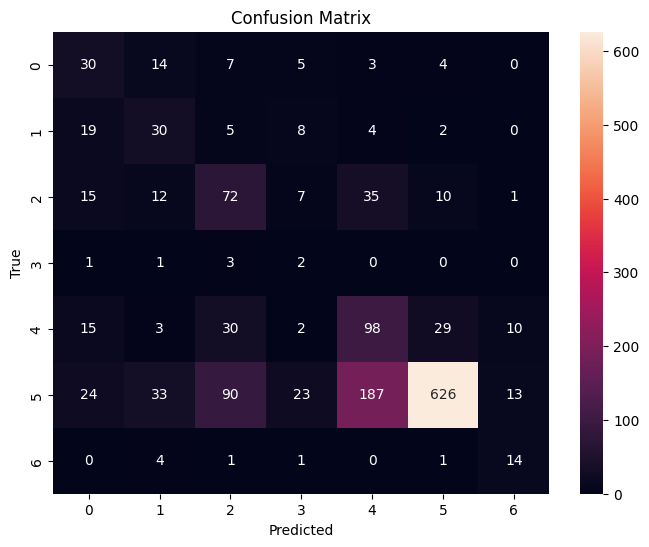

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.show()

## 14. Learning curves

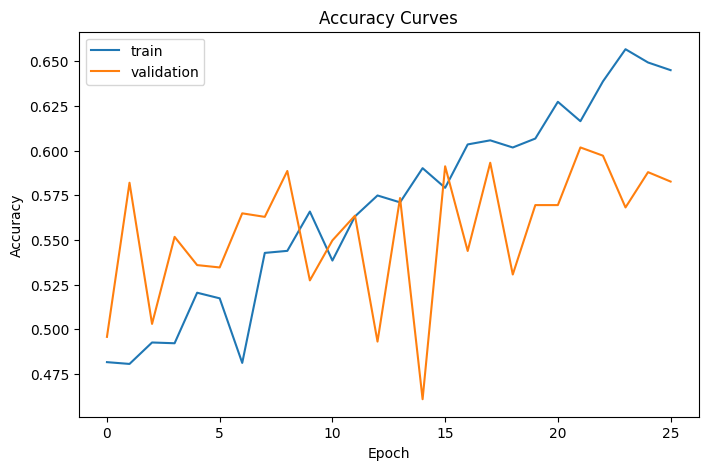

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="train")
plt.plot(val_accuracies, label="validation")

plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

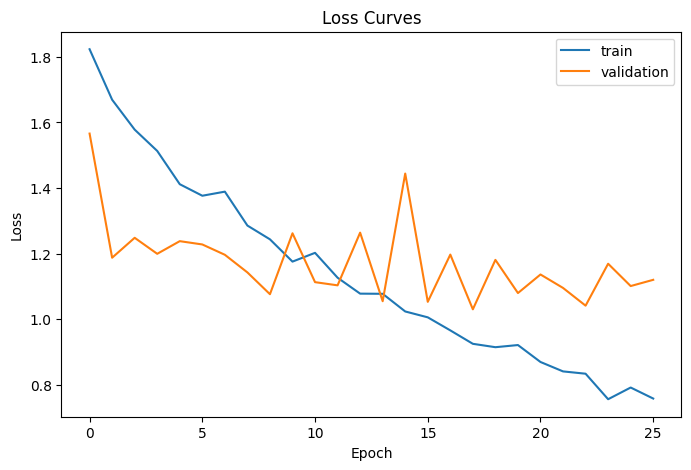

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")

plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

Compared to the initial baseline experiment, overfitting is significantly reduced. Training loss decreases steadily while validation loss remains relatively stable, suggesting improved generalization. However, a moderate gap between training and validation performance remains, indicating residual overfitting.

Validation loss reaches a plateau after the early epochs and no longer improves substantially, supporting the use of early stopping to avoid unnecessary training and retain the best-performing model.

## 16. Conclusions

- A baseline CNN was successfully trained.
- Weighted loss was used to mitigate class imbalance.
- Performance remains limited due to model simplicity.
- Minority classes remain challenging.
- Transfer learning is expected to improve performance.